In [1]:
library(Seurat)

Attaching SeuratObject

Seurat v4 was just loaded with SeuratObject v5; disabling v5 assays and
validation routines, and ensuring assays work in strict v3/v4
compatibility mode



In [2]:
input_files <- c('/mnt/cold1/snaketree/prj/scRNA/dataset/rCASC_Ire_cetuxi/CRC0322_NT_1_3000_dir/filtered_annotated_CRC0322_NT_1_3000.tsv',
                 '/mnt/cold1/snaketree/prj/scRNA/dataset/rCASC_Ire_cetuxi/CRC0327_NT_2_dir/filtered_annotated_CRC0327_NT_2.tsv', 
                 '/mnt/cold1/snaketree/prj/scRNA/dataset/rCASC_longer/CRC0542_NT72h_1_dir/filtered_annotated_CRC0542_NT72h_1.tsv')
                 
samples <- c('CRC0322', 'CRC0327', 'CRC0542')

filtergenes <- ''
# or 
#filtergenes <- 'Graphs/grafo_filtrato_undirect_small.csv'

if (filtergenes != '') {
    nfeatures <- 949
    npc <- 300
    resolution <- 0.3
} else {
    nfeatures <- 1000
    npc <- 20
    resolution <- 0.07
}


In [3]:
# create seurat objects and integrates
input_files_l <- unlist(strsplit(input_files, ','))

createSeurat <- function(file) {
  df <- read.table(gzfile(file), sep=',', header=TRUE, row.names=1)
  res <- CreateSeuratObject(df)
  return(res)
}

data_list <- lapply(input_files_l, createSeurat)

data_list <- lapply(X = data_list, FUN = function(x) {
    x <- NormalizeData(x)
    x <- FindVariableFeatures(x, selection.method = "vst", nfeatures = nfeatures)
})

features <- SelectIntegrationFeatures(object.list = data_list)
anchors <- FindIntegrationAnchors(object.list = data_list, anchor.features = features)
sdata <- IntegrateData(anchorset = anchors) 
DefaultAssay(sdata) <- "integrated"



Warning message:
“The `slot` argument of `SetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Warning message in CheckDuplicateCellNames(object.list = object.list):
“Some cell names are duplicated across objects provided. Renaming to enforce unique cell names.”
Scaling features for provided objects

Finding all pairwise anchors

Warning message:
“Layer counts isn't present in the assay object; returning NULL”
Warning message:
“Layer counts isn't present in the assay object; returning NULL”
Running CCA

Merging objects

Finding

In [ ]:
sdata

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
07:11:51 UMAP embedding parameters a = 0.9922 b = 1.112

07:11:51 Read 10050 rows and found 20 numeric columns

07:11:51 Using Annoy for neighbor search, n_neighbors = 30

07:11:51 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

07:11:52 Writing NN index file to temp file /tmp//RtmpbNhh4Q/fileebc5e554b62d2

07:11:52 Searching Annoy index using 1 thread, search_k = 3000

07:11:55 Annoy recall = 100%

07:11:56 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbor

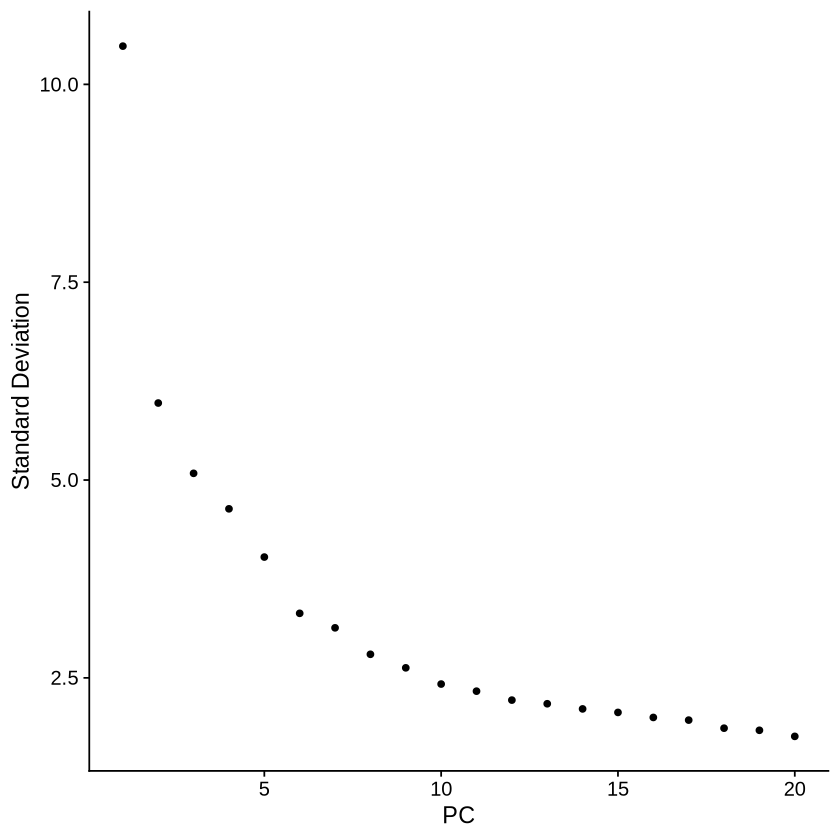

In [4]:
# Scale PCA UMAP on integrated
sdata <- ScaleData(sdata, verbose = FALSE)
sdata <- RunPCA(sdata, verbose = FALSE)

ElbowPlot(sdata)

sdata <- RunUMAP(sdata, reduction = "pca", dims = 1:npc, verbose=F)
sdata <- FindNeighbors(sdata, reduction = "pca", dims = 1:npc, verbose=F)

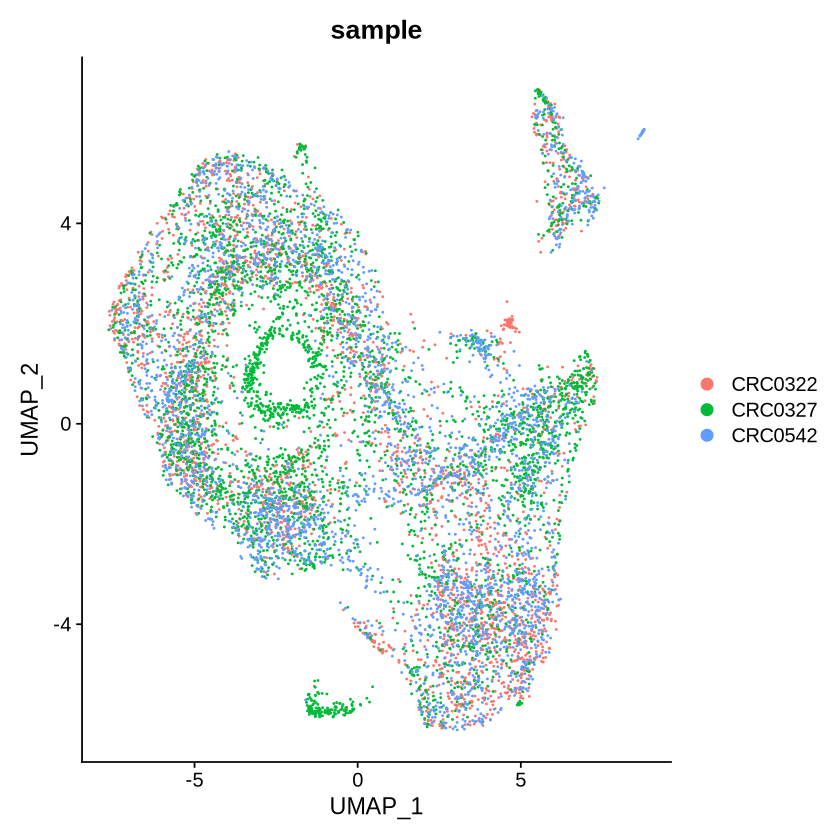

In [5]:
#UMAP with samples
cells <- colnames(sdata)
samples_n <- sapply(strsplit(cells, "_"), function(x){x[[2]]})
sdata$sample <- samples[as.numeric(samples_n)]
DimPlot(sdata, reduction = "umap", group.by='sample')


Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 10050
Number of edges: 386485

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9508
Number of communities: 5
Elapsed time: 1 seconds


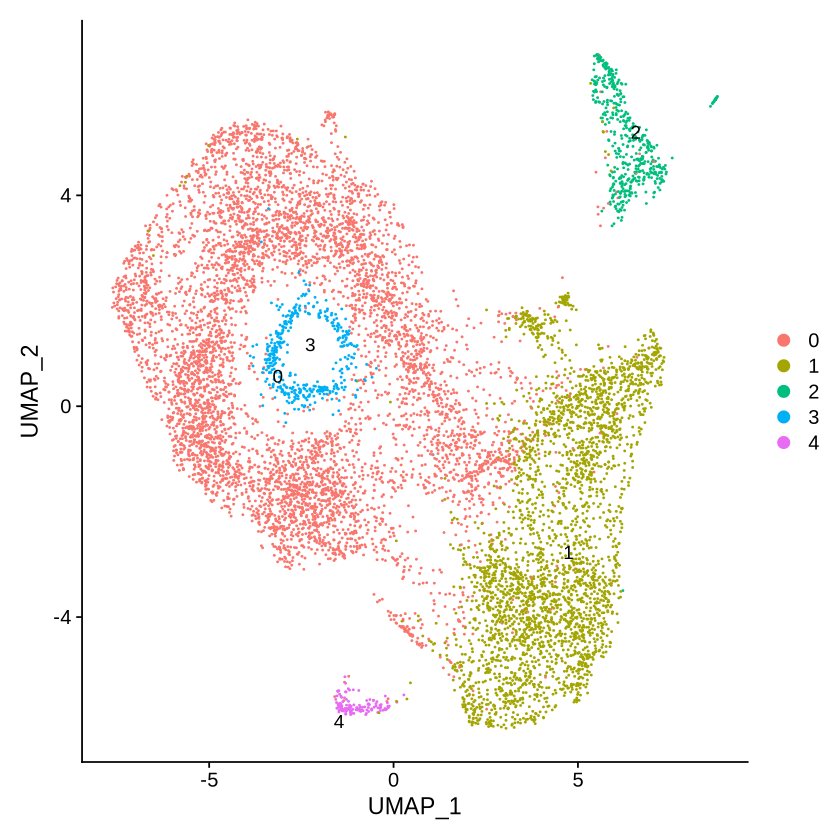

In [6]:
# UMAP with clusters
sdata <- FindClusters(sdata, resolution = resolution)
DimPlot(sdata, reduction = "umap", label = TRUE, repel = TRUE)

In [8]:
filesp <- c('/mnt/cold1/snaketree/prj/scRNA/dataset/KMeans_2/kmeans/CRC0322_NT_1_3000/CRC0322_NT_1_3000_kmeans_2comp.csv',
            '/mnt/cold1/snaketree/prj/scRNA/dataset/KMeans_2/kmeans/CRC0327_NT_2/CRC0327_NT_2_kmeans_2comp.csv',
            '/mnt/cold1/snaketree/prj/scRNA/dataset/KMeans_2/kmeans/CRC0542_NT72h_1/CRC0542_NT72h_1_kmeans_2comp.csv')

load <- function(file) {
  df <- read.csv(file, sep=',', header=TRUE, row.names=1)
  
}
alld <- data.frame()
for (i in seq(1, length(filesp))) {
    data <- read.csv(filesp[i], sep=',', header=TRUE, row.names=1)
    data$cellname <- paste0(rownames(data), '_', i)
    data[data$isPaneth == "filtered", 'isPaneth'] <- 'nPaneth'            
    alld <- rbind(alld, data)
}



[1] TRUE

         
             0    1    2    3    4
  nPaneth 5937 2899   59  409  115
  Paneth    38  184  409    0    0

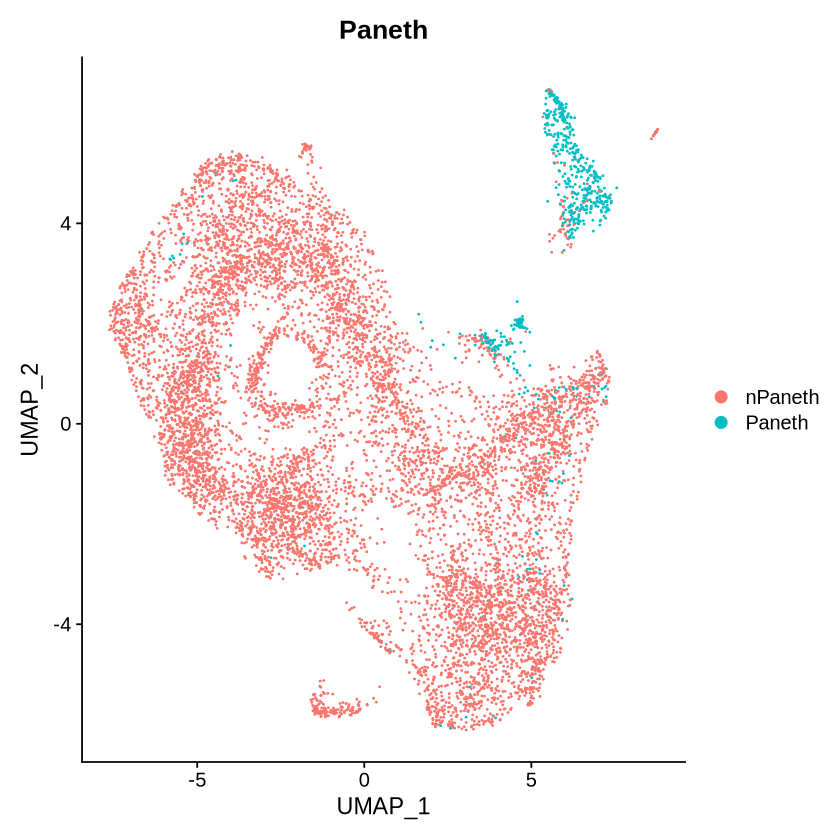

In [9]:
wo <- colnames(sdata)

alld <- alld[match(wo, alld$cellname),]
all(wo == alld$cellname)
sdata$Paneth <- alld$isPaneth
DimPlot(sdata, reduction = "umap", group.by='Paneth')
table(sdata$Paneth, sdata$seurat_clusters)


In [13]:
DefaultAssay(sdata) <- "RNA"

df <- data.frame(row.names=names(sdata$orig.ident), sample=sdata$sample, cluster=sdata$seurat_clusters)

n_cl <- length(unique(df$cluster))
deg <- list()
n_cl <- length(unique(df$cluster))
deg <- list()
for (i in seq(0,(n_cl-1))) {
	cl <- as.data.frame(FindConservedMarkers(sdata, ident.1 = i, verbose = FALSE, grouping.var="sample"))
    deg[[i+1]] <- cl[cl$max_pval < 0.05,]
}

Warning message:
“CRC0322 has fewer than 3 cells in Identity: 3. Skipping CRC0322”
Warning message:
“Identity: 4 not present in group CRC0322. Skipping CRC0322”
Warning message:
“Identity: 4 not present in group CRC0542. Skipping CRC0542”
Warning message:
“Only a single group was tested”


In [14]:
for (i in seq(0,(n_cl-1))) {
    print(paste0('cluster ', i))
    d <- deg[[i+1]]
    d <- d[order(-d$CRC0322_avg_log2FC),]
    print(head(d[, grepl('log2FC', colnames(d))], n=10))
    print(head(d[, grepl('adj', colnames(d))], n=10))
}

[1] "cluster 0"
                       CRC0322_avg_log2FC CRC0542_avg_log2FC CRC0327_avg_log2FC
ENSG00000123416:TUBA1B           2.584610           1.854202          1.2984103
ENSG00000175063:UBE2C            2.380980           2.086804          1.0480854
ENSG00000164104:HMGB2            2.319121           2.160044          1.2922042
ENSG00000188229:TUBB4B           2.132023           1.307011          0.7042941
ENSG00000108106:UBE2S            1.988799           1.782784          0.8307008
ENSG00000170312:CDK1             1.948393           1.374902          1.0114304
ENSG00000088325:TPX2             1.944822           2.176412          0.9181870
ENSG00000148773:MKI67            1.939461           1.669522          1.0682420
ENSG00000100526:CDKN3            1.880465           1.213713          0.5704665
ENSG00000131747:TOP2A            1.805990           2.167952          0.9172285
                       CRC0322_p_val_adj CRC0542_p_val_adj CRC0327_p_val_adj
ENSG00000123416:TUBA1B     

ERROR: Error in -d$CRC0322_avg_log2FC: invalid argument to unary operator


##### save clustering info 
write.table(df, file="/mnt/cold1/snaketree/prj/scRNA/dataset/Graph_NN/notebook/seurat_v4_integration_trainWT_whole.tsv", sep="\t", quote=F, row.names=T)